In [16]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from tinygp import kernels, GaussianProcess
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer import SVI, Trace_ELBO
from numpyro.optim import Adam
import matplotlib.pyplot as plt
import numpy as np


# Define the density function
def rho(x, y, z, e, p, q, rho0, s, a, b):
    #eps = 1e-12
    #r = (jnp.abs(x)**2 + jnp.abs(y)**2 + jnp.abs(z)**2)**0.5
    m = ((jnp.abs(x)**(2 - e) + (jnp.abs(y) / p)**(2 - e) + (jnp.abs(z) / q)**(2 - e)))**(1 / (2 - e)) 
    #m = jnp.maximum(m, eps)
    den = rho0 / ((m / s)**a * (1 + (m / s))**(b - a))
    return den / (p * q)


# Define the model
def model(x, y, z, rho_obs=None):
    #eps = 1e-12
    r = jnp.sqrt(x**2 + y**2 + z**2)
    #r = jnp.maximum(r,eps)
    
    # GP parameters for p(r)
    sigma_p = numpyro.param("sigma_p", jnp.ones(()), constraint=dist.constraints.positive)
    length_scale_p = numpyro.param("length_scale_p", jnp.array(0.5), constraint=dist.constraints.positive)
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r, diag=1e-5, mean=0.0)  
    p = numpyro.sample("p", gp_p.numpyro_dist())
    p = jax.nn.sigmoid(p)

    # GP parameters for f_q (latent function for q)
    sigma_q = numpyro.param("sigma_q", jnp.ones(()), constraint=dist.constraints.positive)
    length_scale_q = numpyro.param("length_scale_q", jnp.array(0.5), constraint=dist.constraints.positive)
    kernel_q = sigma_q**2 * kernels.ExpSquared(length_scale_q)
    gp_q = GaussianProcess(kernel_q, r, diag=1e-5, mean=0.0)
    q = numpyro.sample("q", gp_q.numpyro_dist())
    q = jax.nn.sigmoid(q)  

    # GP parameters for f_e (latent function for e)
    sigma_e = numpyro.param("sigma_e", jnp.ones(()), constraint=dist.constraints.positive)
    length_scale_e = numpyro.param("length_scale_e", jnp.ones(()), constraint=dist.constraints.positive)
    kernel_e = sigma_e**2 * kernels.ExpSquared(length_scale_e)
    gp_e = GaussianProcess(kernel_e, r, diag=1e-5, mean=0.0)
    e = numpyro.sample("e", gp_e.numpyro_dist())
    e = jnp.tanh(e)  

    rho0 = numpyro.param("rho0", 1.0, constraint=dist.constraints.positive)
    s = numpyro.param("s", 1.0, constraint=dist.constraints.positive)
    a = numpyro.param("a", 1.0, constraint=dist.constraints.positive)
    b = numpyro.param("b", 2.0, constraint=dist.constraints.positive)

    # Compute the density
    density = rho(x, y, z, e, p, q, rho0, s, a, b)

    # Observation model
    numpyro.sample("rho_obs", dist.Normal(density, 0.1), obs=rho_obs)


# Use AutoGuide for variational inference
guide = AutoNormal(model)

# Optimizer and inference
optim = Adam(0.01)
svi = SVI(model, guide, optim, Trace_ELBO(10))

# Example usage
# Example input data (replace with actual data)
size = 300
ex = 5
x = jnp.linspace(0.1, ex, size)  
y = jnp.linspace(0.1, ex, size)
z = jnp.linspace(0.1, ex, size)

# Create a 3D grid
#x, y, z = jnp.meshgrid(x_range, y_range, z_range, indexing="ij")
#x = x.flatten()
#y = y.flatten()
#z = z.flatten()
def p_sigmoid(x,y,z):
    r = (jnp.abs(x)**2 + jnp.abs(y)**2 + jnp.abs(z)**2)**0.5
    p = jax.nn.sigmoid(r)
    return p, r
def e_tanh(x,y,z):
    r = (jnp.abs(x)**2 + jnp.abs(y)**2 + jnp.abs(z)**2)**0.5
    e = jnp.tanh(r)
    return e,r

p,r = p_sigmoid(x,y,z)
q,r = p_sigmoid(x,y,z)
e,r = e_tanh(x,y,z)

# Set the random key for reproducibility
key = jax.random.PRNGKey(42)

rho_obs = rho(x, y, z, e, p, q, 1.0, 1.0, 1.0, 2.0)

# Noise parameters
noise_mean = 0.0  # Mean of the noise
noise_std = 0.1   # Standard deviation of the noise

# Generate Gaussian noise
noise = noise_mean + noise_std * jax.random.normal(key, shape=rho_obs.shape)

rho_obs = rho_obs+noise



This breaks if we have input data that is 0 in x,y and z. rho_obs goes to infinity which leads to a ValueError: Normal distribution got invalid loc parameter.

If we add a term that prevents m from being zero we get RuntimeError: Cannot find valid initial parameters. Please check your model again.

If we use an observation that is not 0 it runs and we get results.
In this case if we increase the number of points we again get RuntimeError: Cannot find valid initial parameters. Please check your model again.


swapped from rho 3d grid using meshgrid to just calculationg rho over r, works alot better.

Still confused how we would want to translate rho(r) to a 3d density distribution

One problem that i see is that the modelparameters do not have that much impact on rho(r) so even if we have a good fit for rho(r) this doesnt correspond to a good fit in rho(x,y,z)



In [17]:

results = svi.run(jax.random.PRNGKey(42), 5000, x, y, z, rho_obs=rho_obs)

100%|██████████| 5000/5000 [00:41<00:00, 121.92it/s, init loss: 54406216.0000, avg. loss [4751-5000]: 2140.4262] 


In [18]:
results.params

{'a': Array(1.2410009, dtype=float32),
 'b': Array(2.5902066, dtype=float32),
 'e_auto_loc': Array([-1.6729254 , -0.8632979 , -0.16761774,  0.2966825 ,  0.48466334,
         0.44404736,  0.27443194,  0.09868202, -0.01494178, -0.04624673,
        -0.02887956, -0.0148563 , -0.03469023, -0.08194941, -0.13348977,
        -0.14827658, -0.12441103, -0.04493181,  0.05720666,  0.17209955,
         0.2819475 ,  0.3745178 ,  0.4327702 ,  0.44130647,  0.37550434,
         0.22949299,  0.02840947, -0.19319895, -0.38111565, -0.4979962 ,
        -0.50766504, -0.43337923, -0.29984936, -0.14883341, -0.00963451,
         0.08251467,  0.11717366,  0.09456567,  0.03021589, -0.06042151,
        -0.14855489, -0.21524058, -0.24034584, -0.22767398, -0.18533492,
        -0.14577645, -0.12362643, -0.14219365, -0.18736985, -0.25793752,
        -0.33628538, -0.4020884 , -0.44035798, -0.45814857, -0.45108065,
        -0.41537932, -0.34997186, -0.2525898 , -0.12531921,  0.01549958,
         0.13718386,  0.2047852 

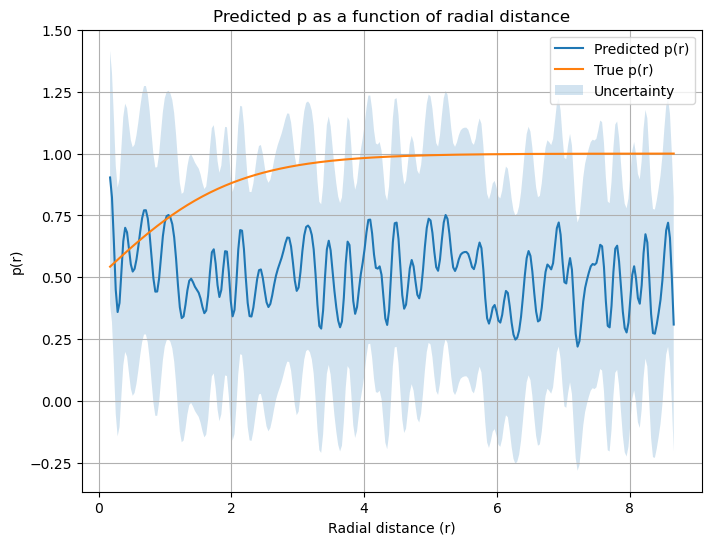

In [19]:
# Extract p values
p_pred = results.params["p_auto_loc"]
p_pred =  jax.nn.sigmoid(p_pred)
# Extract standard deviation for p
p_std = results.params["p_auto_scale"]
p_std =  jax.nn.sigmoid(p_std)

# Plot p(r)
plt.figure(figsize=(8, 6))
plt.plot(r, p_pred, label="Predicted p(r)")
plt.plot(r,p, label="True p(r)")
plt.fill_between(r, p_pred - p_std, p_pred + p_std, alpha=0.2, label="Uncertainty")
plt.xlabel("Radial distance (r)")
plt.ylabel("p(r)")
plt.title("Predicted p as a function of radial distance")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
jnp.mean(p_pred)

Array(0.5125676, dtype=float32)

In [21]:
results.params

{'a': Array(1.2410009, dtype=float32),
 'b': Array(2.5902066, dtype=float32),
 'e_auto_loc': Array([-1.6729254 , -0.8632979 , -0.16761774,  0.2966825 ,  0.48466334,
         0.44404736,  0.27443194,  0.09868202, -0.01494178, -0.04624673,
        -0.02887956, -0.0148563 , -0.03469023, -0.08194941, -0.13348977,
        -0.14827658, -0.12441103, -0.04493181,  0.05720666,  0.17209955,
         0.2819475 ,  0.3745178 ,  0.4327702 ,  0.44130647,  0.37550434,
         0.22949299,  0.02840947, -0.19319895, -0.38111565, -0.4979962 ,
        -0.50766504, -0.43337923, -0.29984936, -0.14883341, -0.00963451,
         0.08251467,  0.11717366,  0.09456567,  0.03021589, -0.06042151,
        -0.14855489, -0.21524058, -0.24034584, -0.22767398, -0.18533492,
        -0.14577645, -0.12362643, -0.14219365, -0.18736985, -0.25793752,
        -0.33628538, -0.4020884 , -0.44035798, -0.45814857, -0.45108065,
        -0.41537932, -0.34997186, -0.2525898 , -0.12531921,  0.01549958,
         0.13718386,  0.2047852 

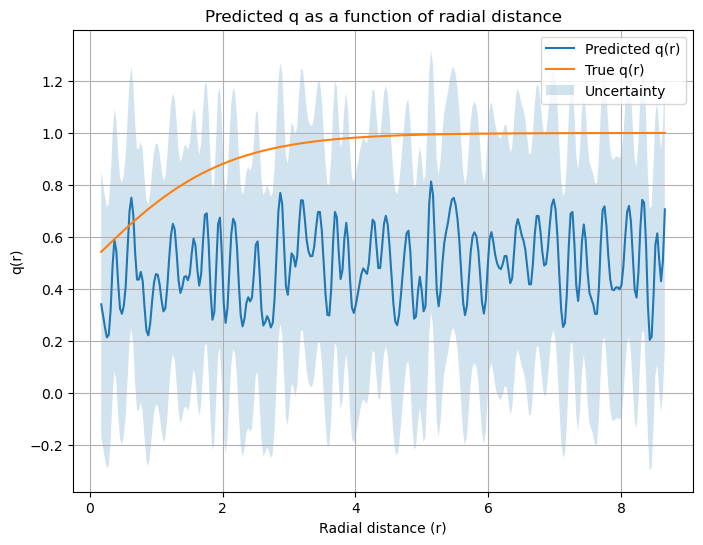

In [22]:
# Extract p values
q_pred = results.params["q_auto_loc"]
q_pred =  jax.nn.sigmoid(q_pred)
# Extract standard deviation for p
q_std = results.params["q_auto_scale"]
q_std =  jax.nn.sigmoid(q_std)

# Plot p(r)
plt.figure(figsize=(8, 6))
plt.plot(r, q_pred, label="Predicted q(r)")
plt.plot(r,q, label="True q(r)")
plt.fill_between(r, q_pred - q_std, q_pred + q_std, alpha=0.2, label="Uncertainty")
plt.xlabel("Radial distance (r)")
plt.ylabel("q(r)")
plt.title("Predicted q as a function of radial distance")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
jnp.mean(q_pred)

Array(0.49274823, dtype=float32)

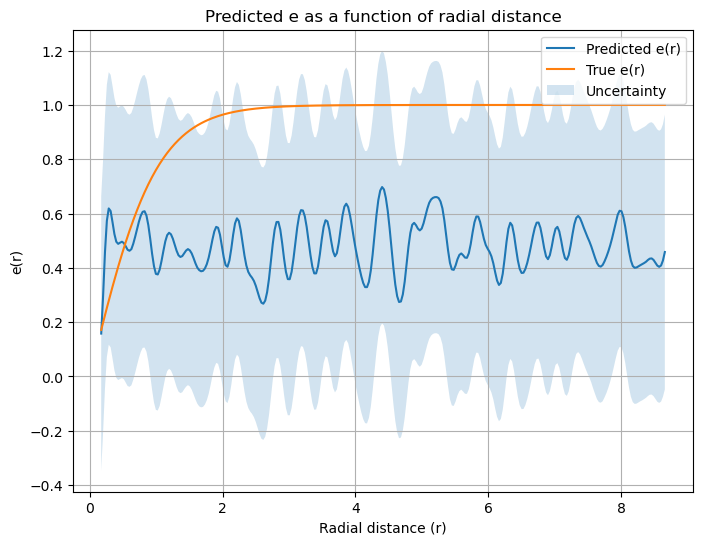

In [24]:
# Extract p values
e_pred = results.params["e_auto_loc"]
e_pred =  jax.nn.sigmoid(e_pred)
# Extract standard deviation for p
e_std = results.params["e_auto_scale"]
e_std =  jax.nn.sigmoid(e_std)
# Sort r and corresponding p values

# Plot p(r)
plt.figure(figsize=(8, 6))
plt.plot(r, e_pred, label="Predicted e(r)")
plt.plot(r,e, label="True e(r)")
plt.fill_between(r, e_pred - e_std, e_pred + e_std, alpha=0.2, label="Uncertainty")
plt.xlabel("Radial distance (r)")
plt.ylabel("e(r)")
plt.title("Predicted e as a function of radial distance")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
jnp.mean(e_pred)

Array(0.47916216, dtype=float32)

In [26]:
# True parameters (used in rho_obs generation)
true_params = {
    "a": 1.0,
    "b": 2.0,
    "rho0": 1.0,
    "s": 1.0
}

# Extract inferred parameters
inferred_params = {
    "a": results.params["a"],
    "b": results.params["b"],
    "rho0": results.params["rho0"],
    "s": results.params["s"]
}

# Print parameter comparison
print("Parameter Comparison:")
for param in true_params:
    print(f"{param}: True = {true_params[param]}, Inferred = {inferred_params[param]}")

Parameter Comparison:
a: True = 1.0, Inferred = 1.2410008907318115
b: True = 2.0, Inferred = 2.5902066230773926
rho0: True = 1.0, Inferred = 1.1319996118545532
s: True = 1.0, Inferred = 0.8805868029594421


In [27]:
rho_true = rho(x, y, z, e, p, q, 1.0, 1.0, 1.0, 2.0)
rho_pred = rho(x, y, z, e_pred, p_pred, q_pred, results.params["rho0"], results.params["s"], results.params["a"], results.params["b"])

In [28]:
np.sum(rho_true)

Array(74.78328, dtype=float32)

In [29]:
np.sum(rho_true - rho_pred)

Array(15.398357, dtype=float32)

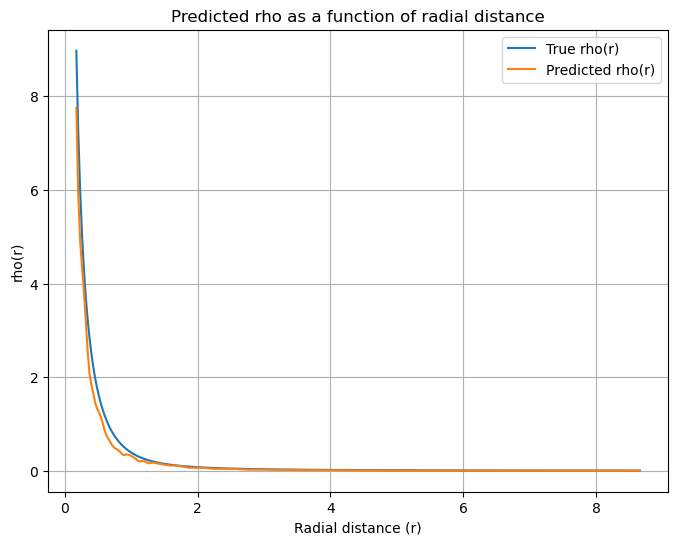

In [30]:
# Plot p(r)
plt.figure(figsize=(8, 6))
plt.plot(r,rho_true, label="True rho(r)")
plt.plot(r, rho_pred, label="Predicted rho(r)")

plt.xlabel("Radial distance (r)")
plt.ylabel("rho(r)")
plt.title("Predicted rho as a function of radial distance")
plt.legend()
plt.grid(True)
plt.show()